In [1]:
import numpy as np
import torch
from os.path import join
import pandas as pd

In [2]:
data_path = '/home/lqr/CLIMA/datasets/section2/processed_data'
data = np.load(join(data_path, 'data.npz'))
gene_sc = torch.tensor(data['arr_0'], dtype=torch.float32, device='cuda:0').squeeze(0)
gene_st = torch.tensor(data['arr_1'], dtype=torch.float32, device='cuda:0').squeeze(0)
# gene_sc = torch.tensor(gene_sc, dtype=torch.float32, device='cuda:0')
# gene_st = torch.tensor(gene_st, dtype=torch.float32, device='cuda:0')

In [3]:
print(gene_sc.shape)
print(gene_st.shape)

torch.Size([1289, 6025])
torch.Size([3366, 6025])


**************************************************
S: torch.Size([1289, 6025, 1])
G: torch.Size([3366, 6025, 1])


100%|██████████| 500/500 [00:04<00:00, 108.19it/s]

Epoch 500: Loss -1.415634036064148
[[ 0.43464196  0.10546076  0.22844686 ...  1.4000831   1.5986384
   1.6101958 ]
 [ 1.2835585   1.3111007   1.3179965  ...  1.9340477   1.4359865
   1.3831488 ]
 [ 1.1125393   1.0770786   1.099893   ...  1.5916098   1.0401722
   1.128475  ]
 ...
 [ 2.3687322   2.3902078   2.3972495  ... -2.7054136   0.76601374
   0.92659765]
 [ 2.462157    2.4659133   2.4728308  ...  2.0973394   1.3684721
   1.5407853 ]
 [ 2.2349129   2.2294412   2.2280045  ... -2.4466095  -0.4033273
   0.2956997 ]]


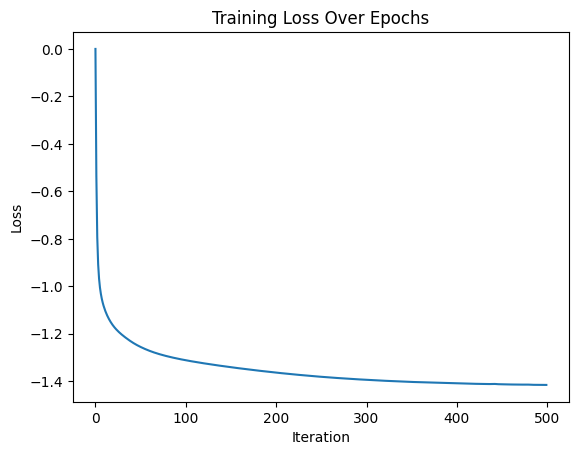

In [4]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [gene_sc],
    [gene_st],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [7]:
# 对每一行应用softmax转换为概率分布
tg = torch.tensor(cos_sim_tg, dtype=torch.float32)
# 对每一行应用softmax得到概率分布
prob = torch.softmax(tg, dim=1)

# 获取每行的最大概率值
max_probs = prob.max(dim=1)[0]

# 找到概率值前50%的索引
k = len(max_probs) // 2  # 取50%
top_indices = torch.argsort(max_probs, descending=True)[:k]

# 获取这些高置信度的mapping
confident_mappings = torch.argmax(tg[top_indices], dim=1)


In [12]:
print(cos_sim_tg.shape)
print(confident_mappings.shape)
print(top_indices.shape)
# confident_mappings
top_indices



(1289, 3366)
torch.Size([644])
torch.Size([644])


tensor([ 644,  914,  683,  564,   65,  208,  224,  195,  625,  624,  583,   74,
         641,   12,  648,  213,  674,  248,  906,  229,  790,  401,  913,  677,
        1176,  629,  900,  846, 1270,  188,  203,  209,  580,  812,  565,  663,
         833,  505,  221, 1092, 1138,  237,  992,  128,  291, 1208,  639,  787,
         647, 1152,  676,   93,  616,    8, 1109, 1249,  502,  916,  110, 1118,
         105,  762,  199,  472, 1284,  268, 1110, 1285,  956,  111,  746,  577,
         198, 1042,   96, 1075,  775,  106,   78, 1095,  370,  656,  238,  581,
         288,  393,  854,  244,  869,   19,  856, 1252,  335,  793,  984,  437,
         219,  108,   73,  272,  773,   81, 1037,  563, 1187,  918,  701,  206,
         889,  540,  765,  122,  172,  738,  118,  483,   56,  783,  574,  718,
         870, 1043,  362, 1253,  429,   91,  371,   90,  451,  760,  336, 1056,
         725,  954, 1085,  705,  742, 1219,  671,  107, 1031,  922,  917,  627,
        1267, 1271, 1083,  501, 1244, 10

In [20]:
from sklearn.decomposition import PCA
import phenograph

sc_conf = gene_sc[top_indices].cpu().numpy()
st_conf = gene_st[confident_mappings].cpu().numpy()
latent_dim = 100
view_gene_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(sc_conf)
view_peak_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(st_conf)
view_gene_label, _, _ = phenograph.cluster(view_gene_feature, random_state=42)
view_peak_label, _, _ = phenograph.cluster(view_peak_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.12771081924438477 seconds
Jaccard graph constructed in 0.4075963497161865 seconds
Wrote graph to binary file in 0.003120899200439453 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.712014
Louvain completed 21 runs in 0.8563234806060791 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.7588376998901367 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06977248191833496 seconds
Jaccard graph constructed in 0.3988313674926758 seconds
Wrote graph to binary file in 0.0028219223022460938 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.895764
Louvain completed 21 runs in 0.8742129802703857 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.737381935119629 seconds


In [21]:
import multi_muse_sc as muse

outputs = muse.dual_muse_fit_predict(
    [sc_conf],
    [st_conf],
    [view_gene_label],
    [view_peak_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=10,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 503.26 	 sc loss: 177.37 	 st loss: 209.26 	 infoNCE: 116.63 	 sc recon: 77.80 	 st recon: 109.26 	 sc sparse: 99.57 	 st sparse: 100.00 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 25/200 	 total loss: 399.26 	 sc loss: 169.13 	 st loss: 173.78 	 infoNCE: 56.34 	 sc recon: 71.51 	 st recon: 75.69 	 sc sparse: 97.62 	 st sparse: 98.10 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 50/200 	 total loss: 381.14 	 sc loss: 166.04 	 st loss: 159.03 	 infoNCE: 56.07 	 sc recon: 70.35 	 st recon: 62.84 	 sc sparse: 95.69 	 st sparse: 96.19 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 0.00
#epoch: 75/200 	 total loss: 360.29 	 sc loss: 163.53 	 st loss: 140.76 	 infoNCE: 56.00 	 sc recon: 69.75 	 st recon: 46.45 	 sc sparse: 93.78 	 st sparse: 94.31 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 

**************************************************
S: torch.Size([644, 6025, 1])
G: torch.Size([644, 6025, 1])


100%|██████████| 500/500 [00:00<00:00, 937.66it/s]

Epoch 500: Loss -1.286726474761963
[[ 4.2795844 -1.4029192  4.2802815 ... -1.7132006  2.7719226  1.7150434]
 [-1.6638776  4.3155975 -0.5791078 ...  2.712283   1.7060479 -0.4329275]
 [ 3.8272405 -2.9078438  3.8289795 ...  3.0816827  3.060459  -4.813689 ]
 ...
 [ 2.1044211  1.4279782  2.080667  ...  2.470441   2.6620555  1.4500164]
 [ 2.358373  -3.1025524  2.3552537 ...  1.934621   2.9010527  2.7721171]
 [ 2.2385929  2.4671602  2.2393124 ...  2.7169538  2.7878668  2.8071618]]


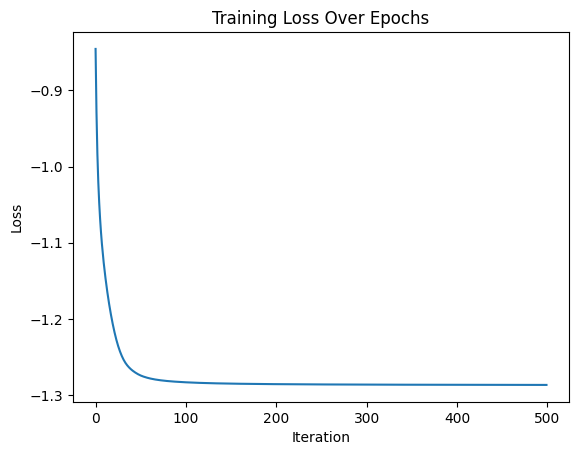

In [17]:
# tangram
confident_tg, _ = tg_cos.read_csv_and_run_tangram(
    [gene_sc[top_indices]],
    [gene_st[confident_mappings]],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [18]:
np.argmax(confident_tg, axis=1)

array([133, 546, 639, 155,  51, 125, 277, 641,   8, 161,  55, 410, 596,
        13,  55,  15, 548,  55, 311, 107, 633,  15, 491,  89,  36, 618,
        55, 578, 258,  75,  13, 535, 542, 392,  88, 235, 287, 253, 382,
       504, 163,  21, 286, 150, 141, 214, 636, 618,  80, 562, 591, 275,
       226, 257, 559, 472, 132, 354, 628, 360, 329, 485, 301, 440, 526,
       382, 402,  55, 147, 624,  43, 283,  85, 441, 365, 564, 520, 308,
       435, 169, 520, 383, 417, 451, 339, 236, 334,  20, 638, 618,  66,
       433, 504, 280, 231, 269, 161, 355, 265, 451, 479, 435, 253, 103,
       187, 630, 135, 176, 299, 380,  22, 149, 140, 344, 206, 434, 132,
       231, 453, 323, 327, 249, 560, 639, 237, 240, 167,   8, 216, 360,
       618, 268, 132, 535, 604,  22, 253, 618, 602,  89, 209,  25, 374,
       433, 380, 275, 198, 552, 484, 100,   7, 277,   4, 436, 399, 241,
        44, 530, 397, 270, 633, 171, 189, 351, 511, 408,  10, 453, 411,
        79, 525, 150, 533, 476, 356, 353, 298, 368, 327, 420, 26

In [14]:
# sim2 = cos_sim_tg.copy()
# prob = np.exp(sim2) / np.sum(np.exp(sim2), axis=1, keepdims=True)
# maxprob = prob.max(axis=1)
# mask = maxprob < 0.0009
# first_hot = np.zeros_like(sim2[0])
# first_hot[0] = 1
# sim2[mask] = first_hot
# # print(maxprob.min())
# # print(maxprob.max())

In [16]:
torch.save(torch.tensor(cos_sim_tg, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg.pt')
# torch.save(torch.tensor(sim2, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg2.pt')

# torch.save(torch.tensor(cca_tg_sim, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cca_tg.pt')

/tmp/ipykernel_1546094/1207400521.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  torch.save(torch.tensor(tg, dtype=torch.float32), '/home/lqr/CLIMA/code/pretrained_weights/org_cos_tg_softmax.pt')


In [17]:
np.argmax(cos_sim_tg, axis=1)

array([1653, 1110,  468, ..., 1386, 1195, 1395])